### Tarea #4 Gema Guerra Valdez (1819110)

#### Requisitos

- Hacer algo análogo a: Encontrar centros de objetos circulares de imágenes de Internet o tomadas por el alumno.

- Compartir hallazgos con el grupo a través de un reporte en Markdown o un PDF en latex.

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img_path = '/content/frutas.jpg' # Cambia por tu imagen
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

In [6]:
print(img_bgr.shape)
print(img_rgb.shape)
print(gray.shape)

(416, 612, 3)
(416, 612, 3)
(416, 612)


<function matplotlib.pyplot.show(close=None, block=None)>

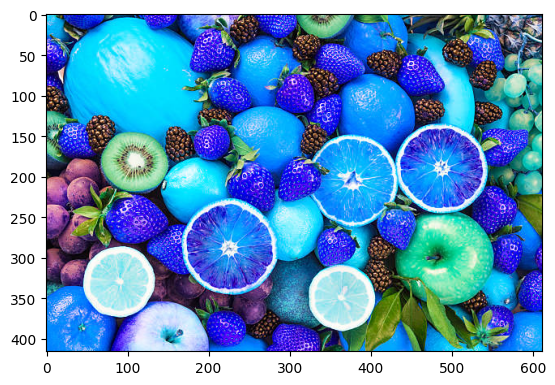

In [9]:
plt.imshow(img_bgr)
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

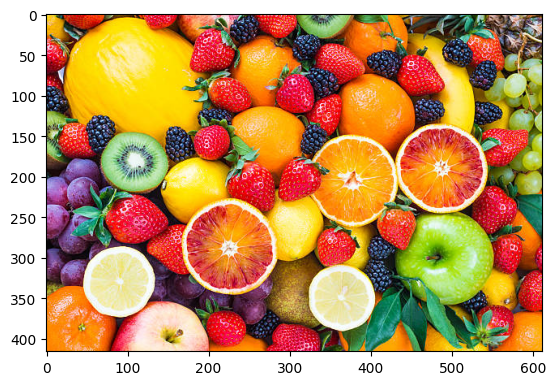

In [10]:
plt.imshow(img_rgb)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

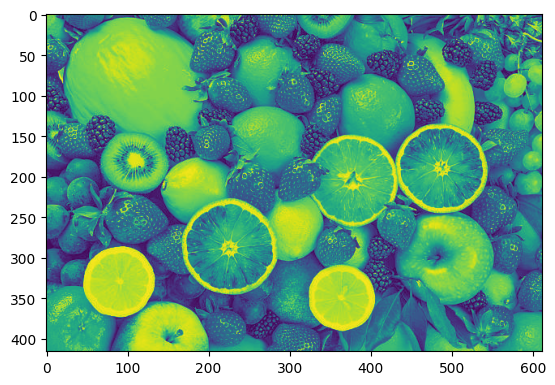

In [11]:
plt.imshow(gray)
plt.show

In [23]:
# Agregar un poco de desenfoque para eliminar ruido
# Esto ayuda a que la Transformada de Hough no detecte falsos círculos
gray_blurred = cv2.medianBlur(gray, 5)

# Histogramas
hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_blurred = cv2.calcHist([gray_blurred], [0], None, [256], [0, 256])

# 4. Detección de objetos circulares (Transformada de Hough)
# Ajusta param1 y param2 según tus imágenes específicas
circles = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,          # Resolución del acumulador
    minDist=60,      # Evita círculos encima de otros
    param1=100,      # Umbral superior para Canny interno
    param2=45,       # ¡Subir este valor reducirá los falsos positivos!
    minRadius=30,
    maxRadius=150)

# Copia para dibujar los resultados
img_out = img_rgb.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for idx, i in enumerate(circles[0, :]):
        # Centro del círculo (x, y)
        centro = (i[0], i[1])
        radio = i[2]

        # Dibujar el contorno del círculo (verde)
        cv2.circle(img_out, centro, radio, (0, 255, 0), 3)
        # Dibujar el centro (punto rojo)
        cv2.circle(img_out, centro, 2, (255, 0, 0), 3)

        print(f"Objeto {idx+1}: Centro en X={i[0]}, Y={i[1]} | Radio={radio}")
else:
    print("No se detectaron círculos.")

# 5. Visualización de Resultados
plt.figure(figsize=(12, 8))

Objeto 1: Centro en X=457, Y=163 | Radio=137
Objeto 2: Centro en X=356, Y=151 | Radio=149
Objeto 3: Centro en X=292, Y=224 | Radio=149
Objeto 4: Centro en X=127, Y=129 | Radio=129
Objeto 5: Centro en X=205, Y=143 | Radio=139
Objeto 6: Centro en X=334, Y=278 | Radio=135
Objeto 7: Centro en X=202, Y=272 | Radio=140
Objeto 8: Centro en X=271, Y=117 | Radio=85
Objeto 9: Centro en X=418, Y=116 | Radio=110
Objeto 10: Centro en X=134, Y=286 | Radio=122
Objeto 11: Centro en X=497, Y=250 | Radio=115
Objeto 12: Centro en X=482, Y=98 | Radio=94
Objeto 13: Centro en X=125, Y=189 | Radio=108
Objeto 14: Centro en X=512, Y=311 | Radio=99
Objeto 15: Centro en X=131, Y=56 | Radio=111
Objeto 16: Centro en X=565, Y=269 | Radio=137
Objeto 17: Centro en X=375, Y=213 | Radio=63
Objeto 18: Centro en X=370, Y=345 | Radio=77
Objeto 19: Centro en X=158, Y=398 | Radio=129
Objeto 20: Centro en X=202, Y=203 | Radio=63
Objeto 21: Centro en X=271, Y=302 | Radio=95
Objeto 22: Centro en X=439, Y=226 | Radio=104
Objeto

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

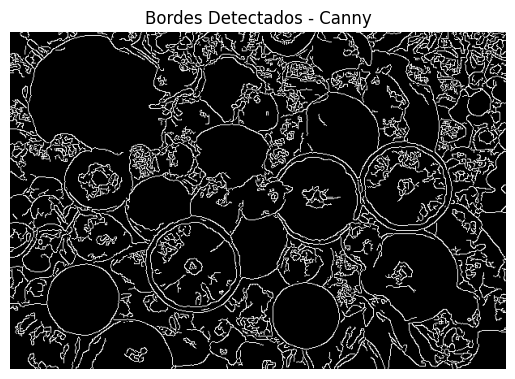

In [20]:
# Detectar bordes usando el detector de Canny
edges = cv2.Canny(gray_blurred, 30, 150)

plt.imshow(edges, cmap='gray')
plt.title('Bordes Detectados - Canny')
plt.axis('off')
plt.show()

In [21]:
B, G, R = cv2.split(img_rgb)

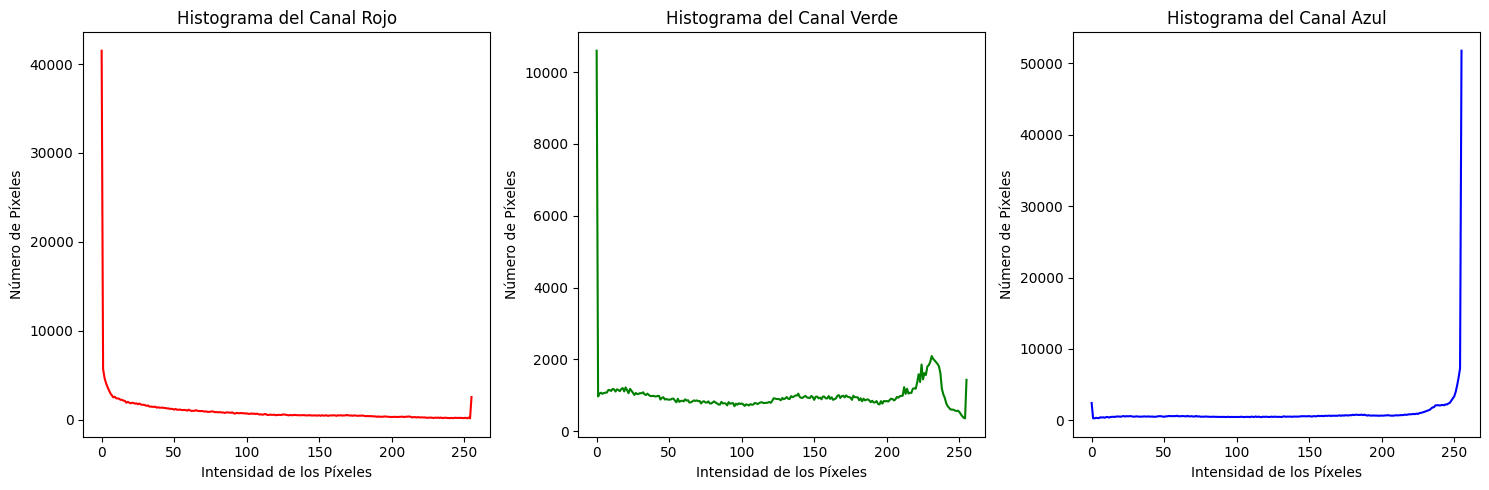

In [22]:
# Calcular el histograma para cada canal
hist_B = cv2.calcHist([B], [0], None, [256], [0, 256])
hist_G = cv2.calcHist([G], [0], None, [256], [0, 256])
hist_R = cv2.calcHist([R], [0], None, [256], [0, 256])

# Visualizar los histogramas
plt.figure(figsize=(15, 5))

plt.subplot(133)
plt.plot(hist_B, color='blue')
plt.title('Histograma del Canal Azul')
plt.xlabel('Intensidad de los Píxeles')
plt.ylabel('Número de Píxeles')

plt.subplot(132)
plt.plot(hist_G, color='green')
plt.title('Histograma del Canal Verde')
plt.xlabel('Intensidad de los Píxeles')
plt.ylabel('Número de Píxeles')

plt.subplot(131)
plt.plot(hist_R, color='red')
plt.title('Histograma del Canal Rojo')
plt.xlabel('Intensidad de los Píxeles')
plt.ylabel('Número de Píxeles')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(611.5), np.float64(415.5), np.float64(-0.5))

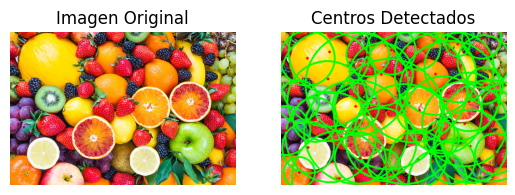

In [24]:
plt.subplot(2, 2, 1)
plt.title("Imagen Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Centros Detectados")
plt.imshow(img_out)
plt.axis('off')

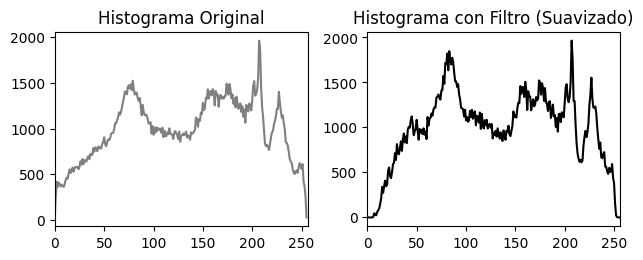

In [16]:
# Mostrar Histogramas
plt.subplot(2, 2, 3)
plt.title("Histograma Original")
plt.plot(hist_original, color='gray')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title("Histograma con Filtro (Suavizado)")
plt.plot(hist_blurred, color='black')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()